# 06 - Patient Clustering Using K-Means

Use the 90% cumulative Autoencoder-selected feature set from Notebook 05.
The target is not used to create clusters, and diabetes_stage is excluded as leakage.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.neural_network import MLPRegressor
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from xgboost import XGBClassifier

np.random.seed(42)
print("Libraries imported successfully.")


Libraries imported successfully.


In [2]:
df = pd.read_csv("../data/diabetes_dataset.csv")
print("Dataset shape:", df.shape)


Dataset shape: (100000, 31)


In [3]:
target_column = "diagnosed_diabetes"
leakage_columns = ["diabetes_stage"]

X = df.drop(columns=[target_column] + leakage_columns)
y = df[target_column].astype(int)

print("Input features:", X.shape[1])
print("Target:", target_column)
print("Excluded:", leakage_columns)


Input features: 29
Target: diagnosed_diabetes
Excluded: ['diabetes_stage']


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])


Training samples: 80000
Testing samples: 20000


In [5]:
numeric_features = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X_train.select_dtypes(include=["object", "string", "category"]).columns.tolist()

print("Numerical features:", len(numeric_features))
print("Categorical features:", len(categorical_features))


Numerical features: 23
Categorical features: 6


In [6]:
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)
feature_names = preprocessor.get_feature_names_out()

print("Processed training shape:", X_train_processed.shape)
print("Processed testing shape:", X_test_processed.shape)


Processed training shape: (80000, 47)
Processed testing shape: (20000, 47)


## Recreate the Autoencoder feature selection

The Autoencoder is trained without the diagnosis target. The same architecture and random seed as Notebook 05 are used, then the 90% cumulative importance threshold is applied.


In [7]:
autoencoder = MLPRegressor(
    hidden_layer_sizes=(32, 12, 32),
    activation="relu",
    solver="adam",
    batch_size=256,
    learning_rate_init=0.001,
    max_iter=50,
    early_stopping=True,
    validation_fraction=0.10,
    n_iter_no_change=5,
    random_state=42
)

autoencoder.fit(X_train_processed, X_train_processed)

print("Autoencoder trained.")
print("Iterations:", autoencoder.n_iter_)
print("Final loss:", round(autoencoder.loss_, 6))


Autoencoder trained.
Iterations: 26
Final loss: 0.086311


In [8]:
encoder_weights = autoencoder.coefs_[0]
raw_importance = np.sum(np.abs(encoder_weights), axis=1)
importance = raw_importance / raw_importance.sum()

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
}).sort_values("Importance", ascending=False).reset_index(drop=True)

feature_importance["Cumulative_Percent"] = feature_importance["Importance"].cumsum() * 100

feature_importance.head(10)


,Feature,Importance,Cumulative_Percent
0,cat__smoking_status_Never,0.034890,3.489031
1,cat__gender_Female,0.034545,6.943495
2,cat__education_level_Highschool,0.034390,10.382528
3,cat__education_level_Postgraduate,0.033854,13.767973
4,cat__education_level_Graduate,0.032826,17.050556
5,cat__gender_Male,0.032708,20.321316
6,cat__employment_status_Employed,0.031485,23.469816
7,cat__education_level_No formal,0.031246,26.594413
8,cat__income_level_Lower-Middle,0.031055,29.699948
9,cat__smoking_status_Current,0.030686,32.768550


In [9]:
threshold = 0.90

first_index = feature_importance.index[
    feature_importance["Cumulative_Percent"] >= 90
][0]

selected_features = feature_importance.loc[:first_index, "Feature"].tolist()

selected_indices = [list(feature_names).index(f) for f in selected_features]

X_train_selected = X_train_processed[:, selected_indices]
X_test_selected = X_test_processed[:, selected_indices]

print("Selected threshold: 90%")
print("Number of selected features:", len(selected_features))
print("Actual cumulative importance:",
      round(feature_importance.loc[first_index, "Cumulative_Percent"], 4), "%")


Selected threshold: 90%
Number of selected features: 36
Actual cumulative importance: 90.0169 %


## K-Means: Elbow Method and Silhouette Score

K-Means is fitted using the 90% Autoencoder-selected features. A 10,000-patient sample is used for K selection so the silhouette calculation remains practical for 100,000 records.


In [10]:
sample_size = min(10000, X_train_selected.shape[0])
rng = np.random.RandomState(42)

sample_indices = rng.choice(
    X_train_selected.shape[0],
    size=sample_size,
    replace=False
)

X_cluster_sample = X_train_selected[sample_indices]

print("Samples used for K selection:", len(X_cluster_sample))


Samples used for K selection: 10000


In [11]:
k_values = range(2, 7)
inertias = []
silhouette_scores = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_cluster_sample)

    inertias.append(kmeans.inertia_)
    silhouette_scores.append(
        silhouette_score(X_cluster_sample, labels)
    )

cluster_evaluation = pd.DataFrame({
    "K": list(k_values),
    "Inertia": inertias,
    "Silhouette_Score": silhouette_scores
})

cluster_evaluation.round(4)


,K,Inertia,Silhouette_Score
0,2,141640.2585,0.1377
1,3,130826.9391,0.0942
2,4,122546.7800,0.1018
3,5,117750.6449,0.0935
4,6,115016.7714,0.0901


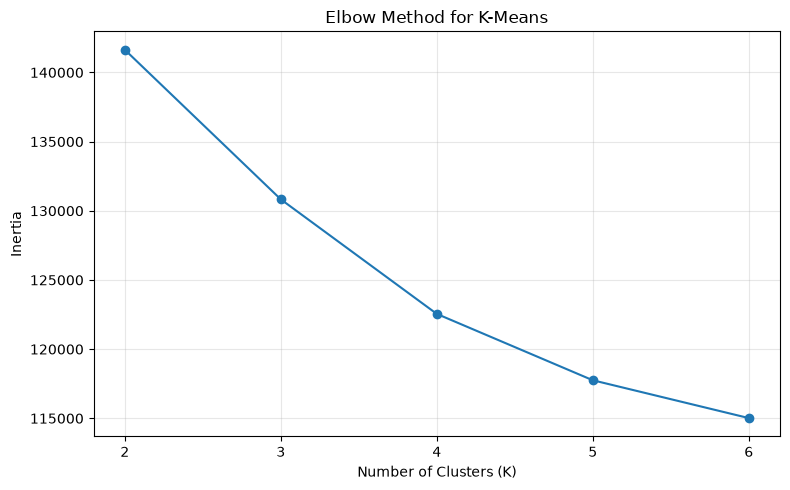

In [12]:
plt.figure(figsize=(8, 5))
plt.plot(cluster_evaluation["K"], cluster_evaluation["Inertia"], marker="o")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for K-Means")
plt.xticks(list(k_values))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


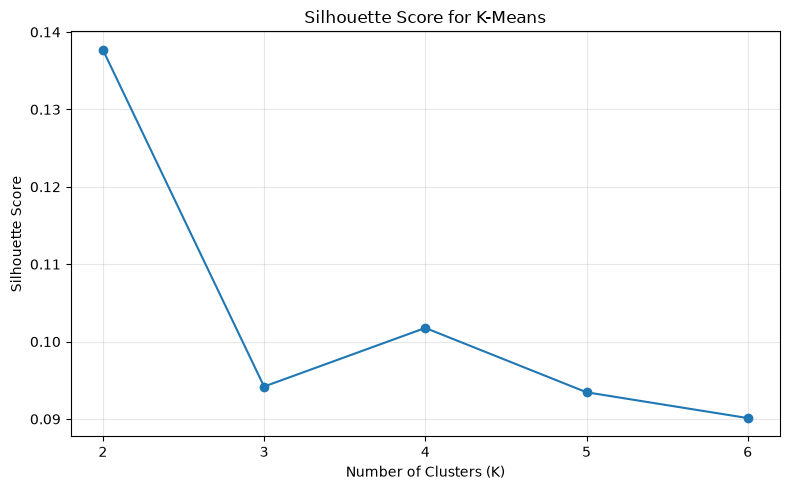

In [13]:
plt.figure(figsize=(8, 5))
plt.plot(cluster_evaluation["K"], cluster_evaluation["Silhouette_Score"], marker="o")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score for K-Means")
plt.xticks(list(k_values))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [14]:
best_k = int(
    cluster_evaluation.loc[
        cluster_evaluation["Silhouette_Score"].idxmax(), "K"
    ]
)

best_silhouette = cluster_evaluation.loc[
    cluster_evaluation["Silhouette_Score"].idxmax(),
    "Silhouette_Score"
]

print("Best K based on highest silhouette score:", best_k)
print("Best silhouette score:", round(best_silhouette, 4))


Best K based on highest silhouette score: 2
Best silhouette score: 0.1377


In [15]:
kmeans_final = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

train_clusters = kmeans_final.fit_predict(X_train_selected)
test_clusters = kmeans_final.predict(X_test_selected)

print("Training cluster counts:")
print(pd.Series(train_clusters).value_counts().sort_index())

print("\nTesting cluster counts:")
print(pd.Series(test_clusters).value_counts().sort_index())


Training cluster counts:
0    62446
1    17554
Name: count, dtype: int64

Testing cluster counts:
0    15611
1     4389
Name: count, dtype: int64


In [16]:
cluster_sizes = pd.DataFrame({
    "Cluster": np.arange(best_k),
    "Training_Count": [
        np.sum(train_clusters == k) for k in range(best_k)
    ]
})

cluster_sizes["Training_Percentage"] = (
    cluster_sizes["Training_Count"] / len(train_clusters) * 100
)

cluster_sizes.round(3)


,Cluster,Training_Count,Training_Percentage
0,0,62446,78.058
1,1,17554,21.943


In [17]:
# Target is used only for post-clustering interpretation, not for K-Means fitting.
cluster_target_analysis = pd.crosstab(
    train_clusters,
    y_train,
    normalize="index"
) * 100

cluster_target_analysis.columns = [
    "No_Diabetes_Percent",
    "Diabetes_Percent"
]
cluster_target_analysis.index.name = "Cluster"

cluster_target_analysis.round(2)


,No_Diabetes_Percent,Diabetes_Percent
Cluster,,
0,45.10,54.90
1,21.85,78.15


## Add Cluster Information to the Predictive Models

The K-Means cluster label is added to the 90% selected features. We then test whether the cluster information improves Random Forest and XGBoost performance.


In [18]:
X_train_clustered = np.column_stack([X_train_selected, train_clusters])
X_test_clustered = np.column_stack([X_test_selected, test_clusters])

print("Features before cluster:", X_train_selected.shape[1])
print("Features after cluster:", X_train_clustered.shape[1])


Features before cluster: 36
Features after cluster: 37


In [19]:
def evaluate_model(model, Xtr, Xte, ytr, yte, name):
    model.fit(Xtr, ytr)
    pred = model.predict(Xte)
    prob = model.predict_proba(Xte)[:, 1]

    return {
        "Model": name,
        "Accuracy": accuracy_score(yte, pred),
        "Precision": precision_score(yte, pred),
        "Recall": recall_score(yte, pred),
        "F1-Score": f1_score(yte, pred),
        "ROC-AUC": roc_auc_score(yte, prob)
    }


In [20]:
rf_cluster = RandomForestClassifier(
    n_estimators=200, random_state=42, n_jobs=-1
)

xgb_cluster = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    n_jobs=-1,
    eval_metric="logloss"
)

cluster_results = pd.DataFrame([
    evaluate_model(
        rf_cluster, X_train_clustered, X_test_clustered,
        y_train, y_test, f"Random Forest - 90% + Cluster (K={best_k})"
    ),
    evaluate_model(
        xgb_cluster, X_train_clustered, X_test_clustered,
        y_train, y_test, f"XGBoost - 90% + Cluster (K={best_k})"
    )
])

cluster_results.round(4)


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Random Forest - 90% + Cluster (K=2),0.9092,0.9961,0.8519,0.9184,0.9406
1,XGBoost - 90% + Cluster (K=2),0.9100,0.9965,0.8531,0.9192,0.9391


## Findings to Record

After execution, record:

1. Selected K.
2. Elbow-method observation.
3. Silhouette score for each K.
4. Cluster sizes.
5. Diabetes percentage in each cluster.
6. RF performance with the cluster feature.
7. XGBoost performance with the cluster feature.
8. Whether adding the cluster improves over the 90% Autoencoder-selected models.

The next notebook can use these results for final model comparison and hyperparameter tuning.
